What Stage 3 does and why it's structured this wayFEniCSx takes the volumetric mesh from Stage 2 and solves a linear elasticity problem — given the material properties, fixed constraints, and applied loads, compute the displacement field and stress tensor at every point in the part. This is the most computationally expensive stage and the one most sensitive to environment issues.The data flow for this stage is:outputs/meshes/<name>_stage02.json     ← handoff from Stage 2
outputs/meshes/<name>.xdmf            ← volume mesh
outputs/meshes/<name>_boundaries.xdmf ← boundary tags
        ↓
src/fea/boundary_conditions.py         ← maps physical group tags → BCs
src/fea/solver.py                      ← assembles and solves the FEA problem
        ↓
outputs/meshes/<name>_displacement.xdmf  ← displacement field
outputs/meshes/<name>_stress.xdmf        ← von Mises stress field
outputs/reports/<name>_stress.png        ← headless render
outputs/meshes/<name>_stage03.json       ← handoff to Stage 4The split between boundary_conditions.py and solver.py matters because boundary condition setup is the part most likely to need tweaking between runs — different load cases, different fixture points — while the solver itself stays constant.

Cell 0 — Parameters (tag: parameters)

In [1]:
# Cell 0 — tagged: parameters
import os
os.chdir("/workspace")

import sys
sys.path.insert(0, "/workspace")

PART_NAME_OVERRIDE = None   # set by pipeline_full.ipynb in sweep mode

STAGE02_HANDOFF    = None     # auto-detect if None
YOUNGS_MODULUS_GPA = 210.0    # override material if needed
POISSONS_RATIO     = 0.3
USE_ITERATIVE_SOLVER = False  # True for meshes > 500k DOFs
YIELD_STRENGTH_MPA = 250.0    # for safety factor calculation (steel default)
RENDER_PLOTS = False

Cell 1 — Load Stage 2 handoff

In [2]:
# Cell 1 — Read handoff from 02_mesh_gmsh.ipynb
import json
from pathlib import Path
from src.geometry.param_schema import PipelineParams

if STAGE02_HANDOFF is None:
    candidates = sorted(Path("outputs/meshes").glob("*_stage02.json"))
    if not candidates:
        raise FileNotFoundError(
            "No stage02 handoff in outputs/meshes/. "
            "Run 02_mesh_gmsh.ipynb first."
        )
    handoff_path = candidates[-1]
else:
    handoff_path = Path(STAGE02_HANDOFF)

handoff   = json.loads(handoff_path.read_text())
part_name = PART_NAME_OVERRIDE if PART_NAME_OVERRIDE else handoff["part_name"]
params_json = f"scad/{part_name}_params.json"

print(f"Loaded handoff: {handoff_path.name}")
print(f"Part:           {part_name}")
print(f"Params:         {params_json}")

pipeline_params  = PipelineParams.from_json(params_json)
geometry_params  = pipeline_params.geometry
load_hints       = handoff["load_hints"]
xdmf_path        = Path(handoff["xdmf_path"])
boundaries_xdmf  = Path(handoff["xdmf_boundaries"])

assert xdmf_path.exists(),       f"XDMF not found: {xdmf_path}"
assert boundaries_xdmf.exists(), f"Boundaries XDMF not found: {boundaries_xdmf}"
print(f"\nMesh:       {xdmf_path}")
print(f"Boundaries: {boundaries_xdmf}")

Loaded handoff: tripod_mount_base_stage02.json
Part:           tripod_mount_base
Params:         scad/tripod_mount_base_params.json

Mesh:       outputs/meshes/tripod_mount_base.xdmf
Boundaries: outputs/meshes/tripod_mount_base_boundaries.xdmf


Cell 2 — Configure material and solver

In [3]:
# Cell 2 — Material and solver config
# Inspectable checkpoint before the expensive solve

material = {
    "youngs_modulus_pa": YOUNGS_MODULUS_GPA * 1e9,
    "poissons_ratio":    POISSONS_RATIO,
    "name":              f"custom_{YOUNGS_MODULUS_GPA}GPa",
}

if USE_ITERATIVE_SOLVER:
    petsc_options = {
        "ksp_type":        "cg",
        "pc_type":         "hypre",
        "pc_hypre_type":   "boomeramg",
        "ksp_rtol":        1e-8,
        "ksp_max_it":      1000,
    }
    print("Solver: CG + BoomerAMG (iterative)")
else:
    petsc_options = {
        "ksp_type":  "preonly",
        "pc_type":   "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    print("Solver: MUMPS direct LU")

print(f"Material:   {material['name']}")
print(f"E:          {YOUNGS_MODULUS_GPA} GPa")
print(f"nu:         {POISSONS_RATIO}")
print(f"Load face:  {load_hints['primary_face']}")
print(f"Load:       {load_hints['load_magnitude_n']} N")

Solver: MUMPS direct LU
Material:   custom_210.0GPa
E:          210.0 GPa
nu:         0.3
Load face:  top
Load:       5000.0 N


Cell 3 — Run FEA solve

In [4]:
# Cell 3 — Solve
from src.fea.solver import run_fea

print("Solving... (this is the expensive step)")
result = run_fea(
    xdmf_path=xdmf_path,
    boundaries_xdmf=boundaries_xdmf,
    part_name=part_name,
    output_dir="outputs/meshes",
    load_hints=load_hints,
    material=material,
    petsc_options=petsc_options,
)

print(f"\nSuccess:          {result.success}")
print(f"Duration:         {result.duration_s}s")
print(f"DOFs:             {result.n_dofs:,}")
print(f"Max displacement: {result.u_max_mm} mm")
print(f"Von Mises max:    {result.von_mises_max} MPa")
print(f"Von Mises mean:   {result.von_mises_mean} MPa")

result.raise_if_failed()

Solving... (this is the expensive step)
  DOFs: 5,271

Success:          True
Duration:         0.155s
DOFs:             5,271
Max displacement: 0.0001 mm
Von Mises max:    1.08 MPa
Von Mises mean:   0.683 MPa


Cell 4 — Safety factor check

In [5]:
# Cell 4 — Safety factor against yield
# This is a go/no-go check BEFORE topology optimization.
# If the base geometry already fails, SIMP won't save it.

safety_factor = YIELD_STRENGTH_MPA / result.von_mises_max if result.von_mises_max else 0

print(f"Yield strength:   {YIELD_STRENGTH_MPA} MPa")
print(f"Von Mises max:    {result.von_mises_max} MPa")
print(f"Safety factor:    {safety_factor:.2f}")

if safety_factor < 1.0:
    print("\n⚠ Part yields under load before optimization.")
    print("  Options:")
    print("  1. Increase wall_thickness in scad/params.json")
    print("  2. Reduce load_magnitude_n in scad/params.json")
    print("  3. Switch to a higher-strength material (increase YOUNGS_MODULUS_GPA)")
elif safety_factor < 1.5:
    print("\n⚠ Safety factor < 1.5 — marginal. Optimization will reduce it further.")
else:
    print(f"\n✓ Safety factor {safety_factor:.2f} — safe to proceed to SIMP.")

Yield strength:   250.0 MPa
Von Mises max:    1.08 MPa
Safety factor:    231.48

✓ Safety factor 231.48 — safe to proceed to SIMP.


Cell 5 — Stress visualization

In [6]:
# Cell 5 — Headless stress render → outputs/reports/
if not RENDER_PLOTS:
    print("Skipping render — set RENDER_PLOTS=True after fixing display")
else:
    import pyvista as pv
    import numpy as np
    from pathlib import Path

    pv.OFF_SCREEN = True

    report_dir = Path("outputs/reports")

    # Read von Mises stress field
    stress_mesh = pv.read(str(result.stress_path))

    pl = pv.Plotter()
    pl.add_mesh(
        stress_mesh,
        scalars="von_mises",
        cmap="hot",
        show_edges=False,
        scalar_bar_args={"title": "Von Mises (Pa)"},
    )
    pl.add_axes()
    pl.view_isometric()
    png_path = report_dir / f"{part_name}_stress.png"
    pl.screenshot(str(png_path))
    pl.close()
    print(f"Stress map saved: {png_path}")

    # Displacement field
    disp_mesh = pv.read(str(result.displacement_path))
    pl2 = pv.Plotter()
    pl2.add_mesh(
        disp_mesh,
        scalars="displacement",
        cmap="coolwarm",
        show_edges=False,
        scalar_bar_args={"title": "Displacement (m)"},
    )
    pl2.add_axes()
    pl2.view_isometric()
    disp_png = report_dir / f"{part_name}_displacement.png"
    pl2.screenshot(str(disp_png))
    pl2.close()
    print(f"Displacement map saved: {disp_png}")

Skipping render — set RENDER_PLOTS=True after fixing display


Cell 6 — Write Stage 3 handoff

In [7]:
# Cell 6 — Write handoff for 04_simp_optimization.ipynb
import json
from pathlib import Path

handoff_out = {
    "stage":              "03_fea",
    "part_name":          part_name,
    "xdmf_path":          str(xdmf_path),
    "xdmf_boundaries":    str(boundaries_xdmf),
    "displacement_path":  str(result.displacement_path),
    "stress_path":        str(result.stress_path),
    "n_dofs":             result.n_dofs,
    "u_max_mm":           result.u_max_mm,
    "von_mises_max_mpa":  result.von_mises_max,
    "von_mises_mean_mpa": result.von_mises_mean,
    "safety_factor":      round(safety_factor, 3),
    "material":           material,
    "load_hints":         load_hints,
}

handoff_path_out = Path("outputs/meshes") / f"{part_name}_stage03.json"
handoff_path_out.write_text(json.dumps(handoff_out, indent=2))
print(f"Handoff written: {handoff_path_out}")
print(json.dumps(handoff_out, indent=2))

Handoff written: outputs/meshes/tripod_mount_base_stage03.json
{
  "stage": "03_fea",
  "part_name": "tripod_mount_base",
  "xdmf_path": "outputs/meshes/tripod_mount_base.xdmf",
  "xdmf_boundaries": "outputs/meshes/tripod_mount_base_boundaries.xdmf",
  "displacement_path": "outputs/meshes/tripod_mount_base_displacement.xdmf",
  "stress_path": "outputs/meshes/tripod_mount_base_stress.xdmf",
  "n_dofs": 5271,
  "u_max_mm": 0.0001,
  "von_mises_max_mpa": 1.08,
  "von_mises_mean_mpa": 0.683,
  "safety_factor": 231.481,
  "material": {
    "youngs_modulus_pa": 210000000000.0,
    "poissons_ratio": 0.3,
    "name": "custom_210.0GPa"
  },
  "load_hints": {
    "primary_face": "top",
    "load_magnitude_n": 5000.0
  }
}


Elements:          7,031
Nodes:             1,757
Von Mises range:   [0.397, 1.080] MPa
Coordinate range:  X=[0.0, 80.0] mm
Displacement range: [16.639432, 99.667265] mm


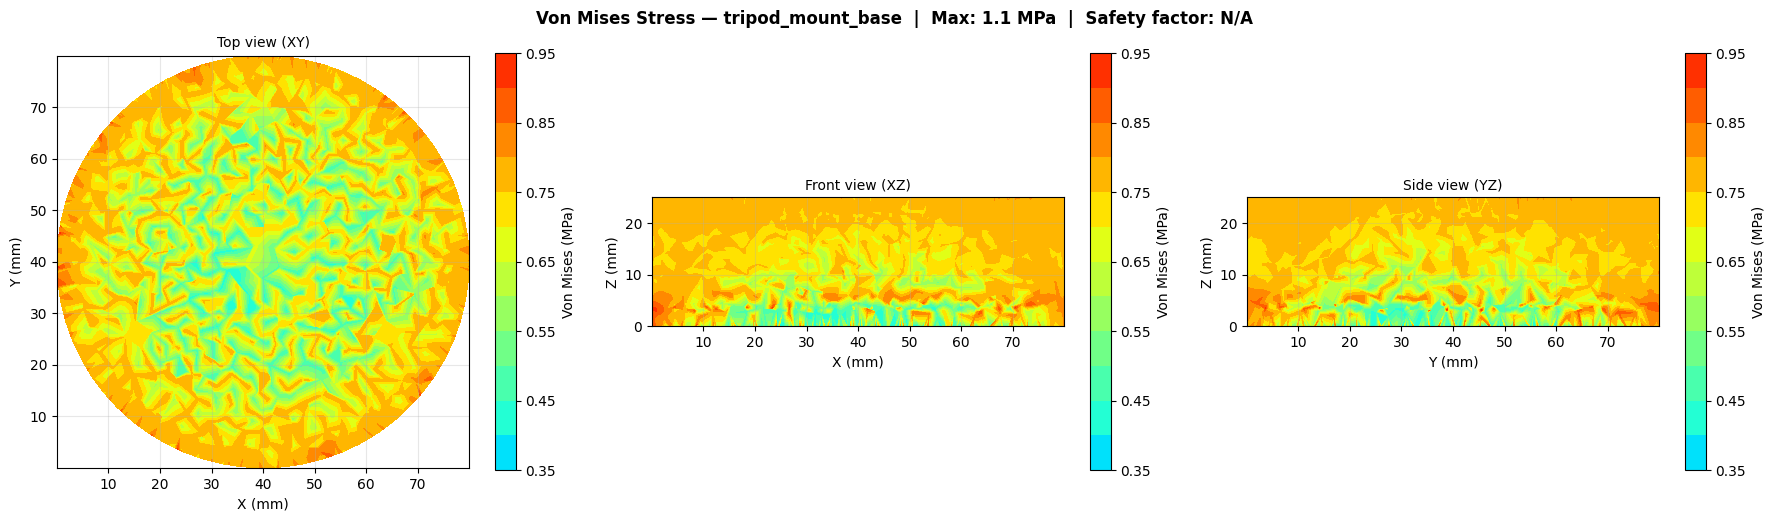

Stress heat map saved: outputs/reports/tripod_mount_base_stress_heatmap.png


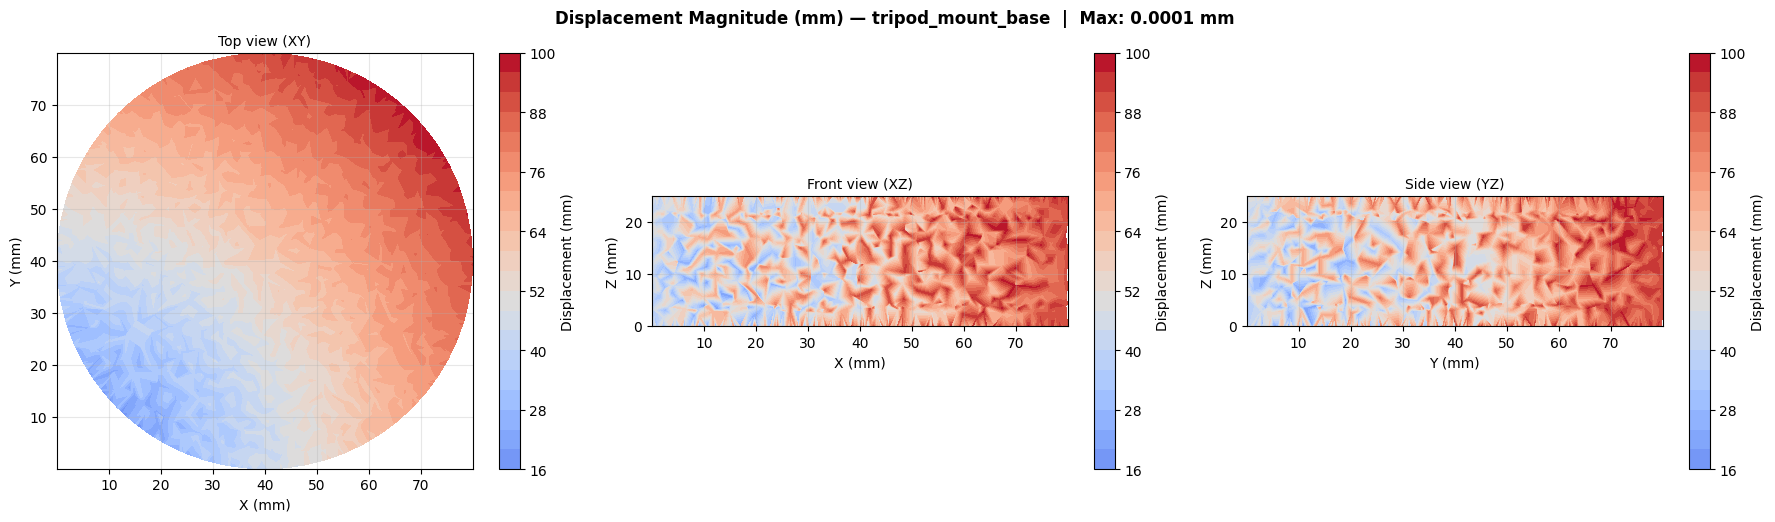

Displacement heat map saved: outputs/reports/tripod_mount_base_displacement_heatmap.png

═══════════════════════════════════════════════════════
  FEA RESULTS SUMMARY
═══════════════════════════════════════════════════════
  Max displacement:  0.0001 mm
  Von Mises max:     1.08 MPa
  Von Mises mean:    0.68 MPa
  High stress zone:  2.1% of elements above 80% max
  → These regions are load-critical — SIMP will retain them
═══════════════════════════════════════════════════════


In [8]:
# ── Heat Map Visualization Cell ──────────────────────────────────────────
# Reads von Mises stress and displacement from Stage 3 HDF5 files
# and produces heat map plots using matplotlib only — no PyVista required.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path
import h5py

report_dir = Path("outputs/reports")
report_dir.mkdir(parents=True, exist_ok=True)

# ── Load stress field ─────────────────────────────────────────────────────
stress_h5 = str(result.stress_path).replace(".xdmf", ".h5")
with h5py.File(stress_h5, "r") as f:
    vm_stress = f["Function/von_mises/0"][:].ravel()   # (n_elements,)
    pts_m     = f["Mesh/Grid/geometry"][:]              # (n_nodes, 3) in metres
    conn      = f["Mesh/Grid/topology"][:]              # (n_elements, 4)

# Convert to mm
pts_mm = pts_m * 1000.0
vm_mpa = vm_stress / 1e6

print(f"Elements:          {len(vm_stress):,}")
print(f"Nodes:             {len(pts_mm):,}")
print(f"Von Mises range:   [{vm_mpa.min():.3f}, {vm_mpa.max():.3f}] MPa")
print(f"Coordinate range:  X=[{pts_mm[:,0].min():.1f}, {pts_mm[:,0].max():.1f}] mm")

# ── Map element stress to nodes by averaging ──────────────────────────────
node_stress = np.zeros(len(pts_mm))
node_count  = np.zeros(len(pts_mm))
for i, tet in enumerate(conn):
    for n in tet:
        node_stress[n] += vm_mpa[i]
        node_count[n]  += 1
mask = node_count > 0
node_stress[mask] /= node_count[mask]

x = pts_mm[:, 0]
y = pts_mm[:, 1]
z = pts_mm[:, 2]

# ── Load displacement field ───────────────────────────────────────────────
disp_h5 = str(result.displacement_path).replace(".xdmf", ".h5")
with h5py.File(disp_h5, "r") as f:
    def find_disp(name, obj):
        if hasattr(obj, 'shape') and obj.ndim == 2 and obj.shape[1] == 3:
            return name
    disp_path = None
    f.visititems(lambda n, o: None)  # traverse
    # Find displacement array
    for k in f.keys():
        try:
            grp = f[k]
            if hasattr(grp, 'keys'):
                for k2 in grp.keys():
                    try:
                        grp2 = grp[k2]
                        if hasattr(grp2, 'keys'):
                            for k3 in grp2.keys():
                                d = grp2[k3][:]
                                if d.ndim == 2 and d.shape[1] == 3:
                                    disp_path = f"{k}/{k2}/{k3}"
                                    break
                        elif hasattr(grp2, 'shape') and grp2.ndim == 2 and grp2.shape[1] == 3:
                            disp_path = f"{k}/{k2}"
                            break
                    except:
                        pass
        except:
            pass

    if disp_path:
        disp_data = f[disp_path][:]
        disp_mag  = np.linalg.norm(disp_data, axis=1) * 1000  # m → mm
        print(f"Displacement range: [{disp_mag.min():.6f}, {disp_mag.max():.6f}] mm")
    else:
        disp_mag = None
        print("⚠ Could not find displacement array")

# ── Map displacement to nodes ─────────────────────────────────────────────
if disp_mag is not None and len(disp_mag) == len(pts_mm):
    node_disp = disp_mag
elif disp_mag is not None:
    # Displacement is at nodes already
    node_disp = disp_mag
else:
    node_disp = np.zeros(len(pts_mm))

# ── Figure 1: Von Mises Stress ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Von Mises Stress — {part_name}  |  "
    f"Max: {vm_mpa.max():.1f} MPa  |  "
    f"Safety factor: {result.safety_factor if hasattr(result, 'safety_factor') else 'N/A'}",
    fontsize=12, fontweight='bold'
)

views = [
    ("Top view (XY)",   x, y, "X (mm)", "Y (mm)"),
    ("Front view (XZ)", x, z, "X (mm)", "Z (mm)"),
    ("Side view (YZ)",  y, z, "Y (mm)", "Z (mm)"),
]

vmin, vmax = 0, vm_mpa.max()

for ax, (title, px, py, xlabel, ylabel) in zip(axes, views):
    try:
        triang = mtri.Triangulation(px, py)
        tcf = ax.tricontourf(triang, node_stress, levels=10,
                              cmap='jet', vmin=vmin, vmax=vmax)
        plt.colorbar(tcf, ax=ax, label="Von Mises (MPa)")
    except Exception as e:
        print(f"tricontourf failed ({e}), using scatter")
        sc = ax.scatter(px, py, c=node_stress, cmap='jet',
                       vmin=vmin, vmax=vmax, s=2, alpha=0.6)
        plt.colorbar(sc, ax=ax, label="Von Mises (MPa)")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
stress_png = report_dir / f"{part_name}_stress_heatmap.png"
plt.savefig(str(stress_png), dpi=150, bbox_inches='tight')
plt.show()
print(f"Stress heat map saved: {stress_png}")

# ── Figure 2: Displacement magnitude ─────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle(
    f"Displacement Magnitude (mm) — {part_name}  |  "
    f"Max: {result.u_max_mm:.4f} mm",
    fontsize=12, fontweight='bold'
)

dmin, dmax = 0, node_disp.max() if node_disp.max() > 0 else 1

for ax, (title, px, py, xlabel, ylabel) in zip(axes2, views):
    try:
        triang = mtri.Triangulation(px, py)
        analyzer = mtri.TriAnalyzer(triang)
        mask = analyzer.get_flat_tri_mask(0.01)
        triang.set_mask(mask)
        tcf = ax.tricontourf(triang, node_disp, levels=20,
                              cmap='coolwarm', vmin=dmin, vmax=dmax)
        plt.colorbar(tcf, ax=ax, label="Displacement (mm)")
    except Exception as e:
        sc = ax.scatter(px, py, c=node_disp, cmap='coolwarm',
                       vmin=dmin, vmax=dmax, s=2, alpha=0.6)
        plt.colorbar(sc, ax=ax, label="Displacement (mm)")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
disp_png = report_dir / f"{part_name}_displacement_heatmap.png"
plt.savefig(str(disp_png), dpi=150, bbox_inches='tight')
plt.show()
print(f"Displacement heat map saved: {disp_png}")

# ── Summary ───────────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("  FEA RESULTS SUMMARY")
print("═"*55)
print(f"  Max displacement:  {result.u_max_mm:.4f} mm")
print(f"  Von Mises max:     {vm_mpa.max():.2f} MPa")
print(f"  Von Mises mean:    {vm_mpa.mean():.2f} MPa")
high_stress = (vm_mpa > 0.8 * vm_mpa.max()).sum() / len(vm_mpa) * 100
print(f"  High stress zone:  {high_stress:.1f}% of elements above 80% max")
print(f"  → These regions are load-critical — SIMP will retain them")
print("═"*55)

Three things travel forward:
stress_path — the von Mises stress XDMF. Stage 4 reads this to initialize the SIMP density field. Elements with high von Mises stress are candidates for keeping material; elements with low stress are candidates for removing it. This is the physical intuition behind SIMP — material is only useful where it's doing mechanical work.
xdmf_path and xdmf_boundaries — Stage 4 re-runs the FEA solve repeatedly during the optimization loop, each time with a modified stiffness field (penalized by the current density). It needs the original mesh and BCs every iteration, not just the stress snapshot.
safety_factor — carried into the handoff so Stage 4 knows the baseline margin. The SIMP optimizer in src/optimization/simp.py uses this to set a minimum compliance target: it won't optimize past the point where the safety factor drops below a user-defined threshold.
The most common failure mode connecting Stage 3 to Stage 4 is the DG0 stress field resolution. If target_element_size in scad/params.json is too coarse, the per-element stress values are averaged over large elements and the SIMP optimizer loses resolution — it can't distinguish loaded from unloaded regions accurately. If your Stage 4 results look like it's removing material uniformly rather than selectively, come back here and halve target_element_size.